# 05 - Results Visualisation

**Goal**: Produce polished, portfolio-quality charts from the Phase 3 analysis.

**Data source**: Pre-computed CSVs saved by notebook 04 (no GEE calls needed here).

**Outputs**:
1. Stacked area chart - land cover composition 1990-2023
2. Sankey transition diagram - where each class went between 1990 and 2023
3. Side-by-side bar chart - 1990 vs 2023 class areas
4. Key findings summary

**Phase**: 3 - Results

In [16]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import plotly.graph_objects as go
from IPython.display import display, IFrame

from pipeline.config import CLASS_NAMES, CLASS_COLORS

print('All libraries loaded OK')

All libraries loaded OK


In [17]:
area_df  = pd.read_csv('../data/processed/area_time_series.csv')
trans_df = pd.read_csv('../data/processed/transition_matrix_1990_2023.csv', index_col=0)

ACTIVE_CLASSES = [0, 2, 3, 4]
ACTIVE_NAMES   = [CLASS_NAMES[i] for i in ACTIVE_CLASSES]
ACTIVE_COLORS  = [CLASS_COLORS[n] for n in ACTIVE_NAMES]
TARGET_YEARS   = sorted(area_df['year'].unique().tolist())

pivot = area_df.pivot(index='year', columns='class_name', values='area_km2')

print('Area data loaded:')
print(pivot.round(1).to_string())
print(f'\nTransition matrix loaded: {trans_df.shape[0]}x{trans_df.shape[1]}')

Area data loaded:
class_name  Agriculture  Barren/Volcanic  Urban/Built-up  Water/Wetland
year                                                                   
1990              203.3            189.2           359.4           58.4
1995              136.3            263.7           297.6           59.4
2000              318.6            428.1           196.1           14.6
2002              228.8            472.0           233.9            7.2
2010              234.0            379.3           168.5           17.0
2015              335.7            469.5           147.1            3.9
2020              324.2            452.5           170.1            5.3
2023              331.0            479.1           138.2            5.0

Transition matrix loaded: 4x4


## 1. Stacked Area Chart

Shows how much of Lanzarote each land cover class occupied each year.
The 2005 dip is a Landsat 7 SLC-off artefact (scan line corrector failure, 2003-2013)
and not a real land cover signal - treat 2005 as a data gap.

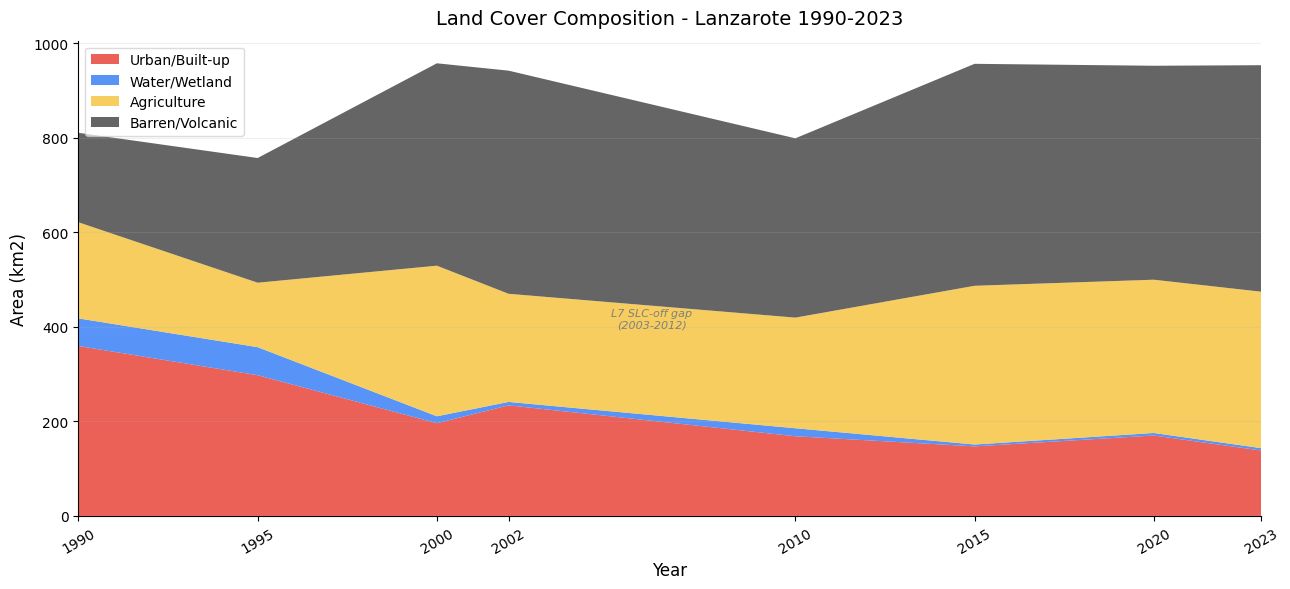

Saved to data/processed/stacked_area_chart.png


In [18]:
# Reorder columns to match ACTIVE_NAMES for stacking
stack_data = pd.DataFrame({
    n: area_df[area_df['class_name'] == n].set_index('year')['area_km2']
    for n in ACTIVE_NAMES
}).fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))

ax.stackplot(
    stack_data.index,
    [stack_data[n].values for n in ACTIVE_NAMES],
    labels=ACTIVE_NAMES,
    colors=ACTIVE_COLORS,
    alpha=0.85,
)

# Annotate the L7 SLC-off gap period (2003-2012, no clean data)
ax.axvspan(2002, 2010, alpha=0.08, color='white', zorder=0)
ax.text(2006, stack_data.values.max() * 0.92,
        'L7 SLC-off gap\n(2003-2012)', ha='center', va='top',
        fontsize=8, color='grey', style='italic')

ax.set_xlim(TARGET_YEARS[0], TARGET_YEARS[-1])
ax.set_ylim(0)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Area (km2)', fontsize=12)
ax.set_title('Land Cover Composition - Lanzarote 1990-2023', fontsize=14, pad=12)
ax.set_xticks(TARGET_YEARS)
ax.set_xticklabels(TARGET_YEARS, rotation=30)
ax.legend(loc='upper left', fontsize=10, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('../data/processed/stacked_area_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/stacked_area_chart.png')

## 2. Sankey Transition Diagram (1990 - 2023)

Each flow shows how many km2 of a 1990 class became a different class by 2023.
Flows staying in the same colour = stable. Flows crossing to a different colour = change.

Built with Plotly - hover over flows to see exact km2 values.

In [19]:
# Node layout: 4 source nodes (1990) on left, 4 target nodes (2023) on right
n = len(ACTIVE_NAMES)
node_labels  = [f'{name}\n1990' for name in ACTIVE_NAMES] +                [f'{name}\n2023' for name in ACTIVE_NAMES]
node_colors  = ACTIVE_COLORS + ACTIVE_COLORS

sources, targets, values, link_colors = [], [], [], []

for i, from_name in enumerate(ACTIVE_NAMES):
    for j, to_name in enumerate(ACTIVE_NAMES):
        val = trans_df.loc[from_name, to_name]
        if val > 0.5:   # skip negligible flows
            sources.append(i)
            targets.append(n + j)
            values.append(round(val, 1))
            # Use from-class colour with transparency
            hex_c = ACTIVE_COLORS[i].lstrip('#')
            r, g, b = int(hex_c[0:2],16), int(hex_c[2:4],16), int(hex_c[4:6],16)
            link_colors.append(f'rgba({r},{g},{b},0.45)')

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20,
        thickness=25,
        label=node_labels,
        color=node_colors,
        line=dict(color='white', width=0.5),
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    ),
))

fig.update_layout(
    title=dict(
        text='Land Cover Transitions 1990 - 2023, Lanzarote (km2)',
        font=dict(size=15),
    ),
    font=dict(size=11),
    width=900,
    height=500,
    paper_bgcolor='white',
)

sankey_path = '../data/processed/sankey_1990_2023.html'
fig.write_html(sankey_path, include_plotlyjs='cdn')
display(IFrame(sankey_path, width=920, height=520))
print(f'Saved to {sankey_path}')

Saved to ../data/processed/sankey_1990_2023.html


## 3. Class Areas: 1990 vs 2023

Grouped bar chart showing the net change in each class over 33 years.
Note: changes partly reflect classifier noise (OA 66.7%) as well as real land cover change.
The Agriculture/Barren/Volcanic confusion is the main source of uncertainty.

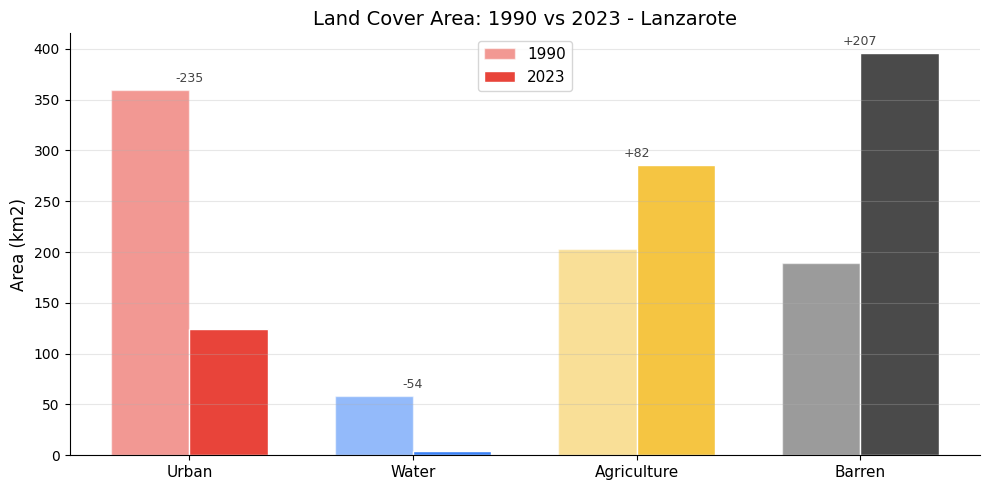

Saved to data/processed/area_comparison_1990_2023.png


In [20]:
areas_1990 = {n: trans_df.loc[n].sum() for n in ACTIVE_NAMES}   # row totals = 1990 area
areas_2023 = {n: trans_df[n].sum()     for n in ACTIVE_NAMES}   # col totals = 2023 area

x      = np.arange(len(ACTIVE_NAMES))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_90 = ax.bar(x - width/2, [areas_1990[n] for n in ACTIVE_NAMES],
                 width, label='1990', color=ACTIVE_COLORS, alpha=0.55, edgecolor='white')
bars_23 = ax.bar(x + width/2, [areas_2023[n] for n in ACTIVE_NAMES],
                 width, label='2023', color=ACTIVE_COLORS, alpha=1.0,  edgecolor='white')

# Delta labels above each pair
for i, name in enumerate(ACTIVE_NAMES):
    delta = areas_2023[name] - areas_1990[name]
    sign  = '+' if delta >= 0 else ''
    ax.text(x[i], max(areas_1990[name], areas_2023[name]) + 5,
            f'{sign}{delta:.0f}', ha='center', va='bottom', fontsize=9, color='#444')

ax.set_xticks(x)
ax.set_xticklabels([n.split('/')[0] for n in ACTIVE_NAMES], fontsize=11)
ax.set_ylabel('Area (km2)', fontsize=12)
ax.set_title('Land Cover Area: 1990 vs 2023 - Lanzarote', fontsize=14)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/area_comparison_1990_2023.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/area_comparison_1990_2023.png')

## 4. Key Findings

In [21]:
total_1990 = sum(areas_1990.values())
total_2023 = sum(areas_2023.values())

stable_km2  = sum(trans_df.loc[n, n] for n in ACTIVE_NAMES)
changed_km2 = trans_df.values.sum() - stable_km2
changed_pct = changed_km2 / trans_df.values.sum() * 100

print('=' * 55)
print('  LANZAROTE LAND COVER CHANGE  1990 - 2023')
print('=' * 55)
print(f'  Total classified area : {total_2023:.0f} km2')
print(f'  Stable 1990-2023      : {stable_km2:.0f} km2  ({100-changed_pct:.1f}%)')
print(f'  Changed 1990-2023     : {changed_km2:.0f} km2  ({changed_pct:.1f}%)')
print()
print('  Class areas (km2):')
print(f'  {"Class":<22} {"1990":>6}  {"2023":>6}  {"Delta":>7}')
print('  ' + '-' * 44)
for name in ACTIVE_NAMES:
    a90  = areas_1990[name]
    a23  = areas_2023[name]
    diff = a23 - a90
    sign = '+' if diff >= 0 else ''
    print(f'  {name:<22} {a90:>6.0f}  {a23:>6.0f}  {sign}{diff:>6.0f}')
print()
print('  Classifier: Random Forest, 200 trees, OA 66.7%, kappa 0.52')
print('  Imagery   : Landsat Collection 2 Level-2 (USGS/NASA)')
print('  Labels    : CORINE Land Cover 2018 (Copernicus/EEA)')
print('=' * 55)

  LANZAROTE LAND COVER CHANGE  1990 - 2023
  Total classified area : 809 km2
  Stable 1990-2023      : 333 km2  (41.2%)
  Changed 1990-2023     : 476 km2  (58.8%)

  Class areas (km2):
  Class                    1990    2023    Delta
  --------------------------------------------
  Urban/Built-up            359     124    -235
  Water/Wetland              58       4     -54
  Agriculture               203     285  +    82
  Barren/Volcanic           189     395  +   207

  Classifier: Random Forest, 200 trees, OA 66.7%, kappa 0.52
  Imagery   : Landsat Collection 2 Level-2 (USGS/NASA)
  Labels    : CORINE Land Cover 2018 (Copernicus/EEA)
